In [165]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score

In [166]:
# Gerando dados sintéticos
X, y = make_classification(
    n_samples=5000,
    n_features=5,
    n_informative=3,
    n_redundant=1,
    n_classes=2,
    class_sep=1.0,
    random_state=42
)

df = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(5)])
df['target'] = y

In [167]:
df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,target
0,1.379235,1.200567,2.320260,-0.577565,1.168878,1
1,0.307273,-0.799876,0.725749,0.757629,0.642210,1
2,1.351406,0.786552,1.912284,-0.709965,0.772449,1
3,0.433977,-0.367866,-0.509308,1.538812,-0.987807,1
4,-1.293903,-1.970693,-1.162020,-0.236831,0.200332,0


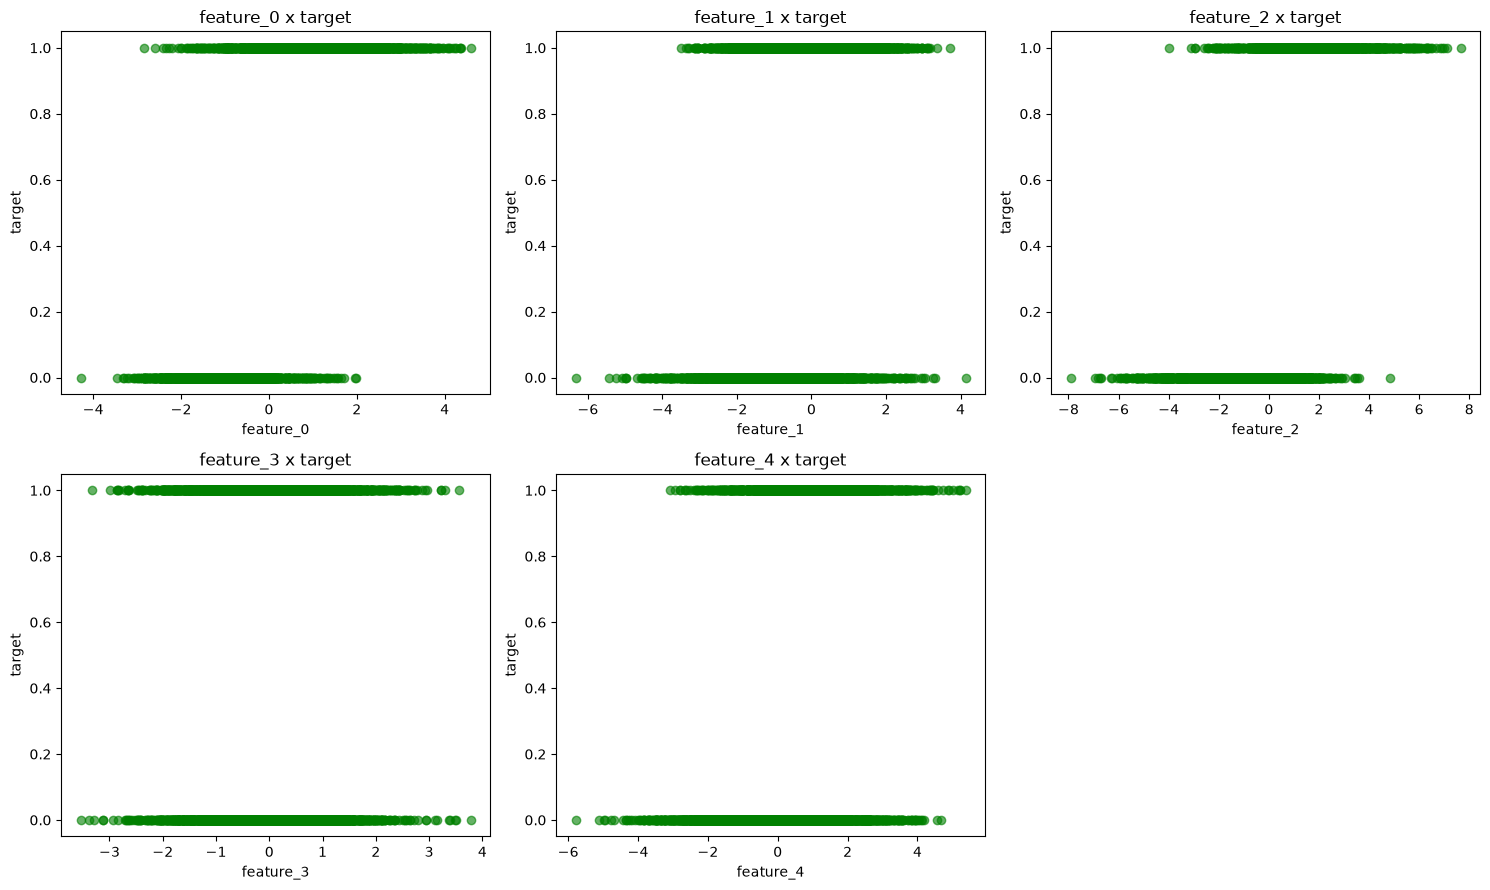

In [168]:
figs, axes = plt.subplots(2, 3, figsize=(15,9))

for i, ax in zip(df.columns[:-1], axes.flatten()):
    ax.scatter(x=df[i], y=df['target'], color='green', alpha=0.6)

    ax.set_title(f"{i} x target")
    ax.set_xlabel(i)
    ax.set_ylabel("target")

for ax in axes.flatten()[len(df.columns[:-1]):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [169]:
# Divisão em conjuntos de treino, validação e teste
X = df.drop(columns=["target"])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_validation, y_train, y_validation = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

print("=== TAMANHO DOS CONJUNTOS DE DADOS ===")
print(f"Treino: {len(X_train)} | Validação: {len(X_validation)} | Teste: {len(X_test)}\n")

=== TAMANHO DOS CONJUNTOS DE DADOS ===
Treino: 3000 | Validação: 1000 | Teste: 1000



In [170]:
bayes = Pipeline([
    ('scale', StandardScaler()),
    ('bayes', GaussianNB())
])

bayes.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scale', ...), ('bayes', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['feature_0','feature_1','feature_2','feature_3','feature_4']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.90      0.87      0.89       507
           1       0.87      0.90      0.89       493

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000

=== MATRIZ DE CONFUSÃO PARA O MODELO NB ===


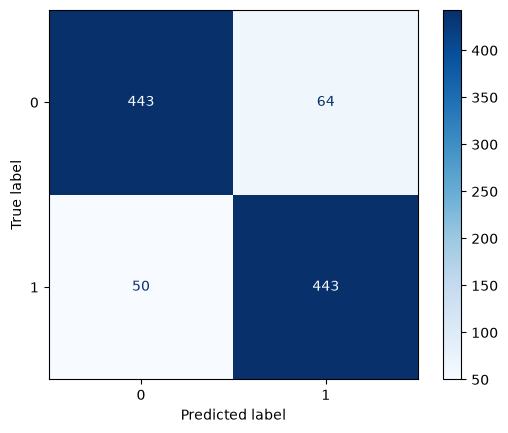

In [171]:
bayes_val = bayes.predict(X_validation)

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_validation, bayes_val))

cm = confusion_matrix(y_validation, bayes_val)
print(f"=== MATRIZ DE CONFUSÃO PARA O MODELO NB ===")
ConfusionMatrixDisplay(cm).plot(cmap=plt.cm.Blues)
plt.show()

In [172]:
logistic = Pipeline([
    ('scale', StandardScaler()),
    ('logistic_reg', LogisticRegression())
])

logistic.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scale', ...), ('logistic_reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['feature_0','feature_1','feature_2','feature_3','feature_4']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.90      0.91      0.91       507
           1       0.91      0.90      0.90       493

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000

=== MATRIZ DE CONFUSÃO PARA O MODELO DE REGRESSÃO LOGÍSTICA ===


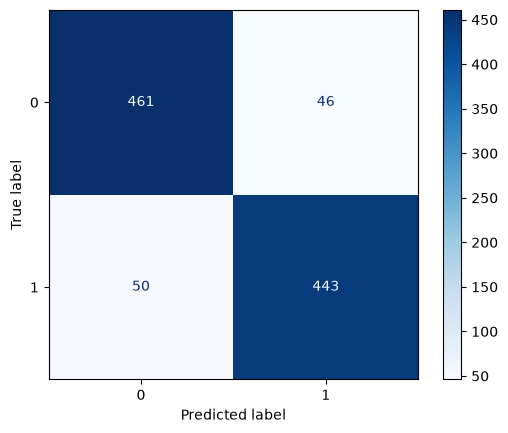

In [173]:
logistic_val = logistic.predict(X_validation)

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_validation, logistic_val))

cm = confusion_matrix(y_validation, logistic_val)
print(f"=== MATRIZ DE CONFUSÃO PARA O MODELO DE REGRESSÃO LOGÍSTICA ===")
ConfusionMatrixDisplay(cm).plot(cmap=plt.cm.Blues)
plt.show()

In [174]:
# Inferência para o conjunto de teste
print("="*50)
print("=== AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ===")

bayes_test = bayes.predict(X_test)
logistic_test = logistic.predict(X_test)

=== AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ===


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.49      0.49      0.49       507
           1       0.48      0.48      0.48       493

    accuracy                           0.49      1000
   macro avg       0.49      0.49      0.49      1000
weighted avg       0.49      0.49      0.49      1000

=== MATRIZ DE CONFUSÃO PARA O MODELO NB ===


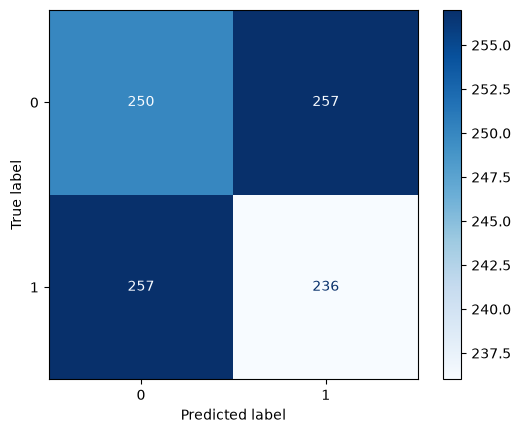

In [175]:
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_validation, bayes_test))

cm = confusion_matrix(y_validation, bayes_test)
print(f"=== MATRIZ DE CONFUSÃO PARA O MODELO NB ===")
ConfusionMatrixDisplay(cm).plot(cmap=plt.cm.Blues)
plt.show()

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.49      0.49      0.49       507
           1       0.48      0.48      0.48       493

    accuracy                           0.48      1000
   macro avg       0.48      0.48      0.48      1000
weighted avg       0.48      0.48      0.48      1000

=== MATRIZ DE CONFUSÃO PARA O MODELO DE REGRESSÃO LOGÍSTICA ===


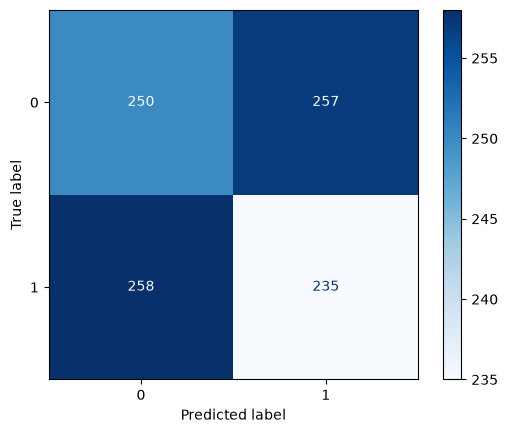

In [176]:
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_validation, logistic_test))

cm = confusion_matrix(y_validation, logistic_test)
print(f"=== MATRIZ DE CONFUSÃO PARA O MODELO DE REGRESSÃO LOGÍSTICA ===")
ConfusionMatrixDisplay(cm).plot(cmap=plt.cm.Blues)
plt.show()